# ECO204 Introduction to Finance - Empirical Project

Shubh Lashkery

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

: 

To test the predictive power of the ILS, we use a simple method used by Fama (1984) to test this hypothesis on currency markets.

$$ \pi_{t+k} - \pi_t = \alpha + \beta (ils_{t,t+k} - \pi_t) + \varepsilon_{t+k},$$

where $\pi_t$ is the annualised monthly inflation rate, $ils_{t,t+k}$ is the inflation-linked swap initiated at $t$, $k$ is the horizon of the ILS, $\varepsilon_{t+k}$ is a normally distributed error term, and $\alpha$ and $\beta$ are the OLS regression coefficients.

This equation is meant to verify to what extent the change in the ilscpiation rate
between $t + k$ and $t$ is reflected in the ILS with horizon $t + k$ at time point $t$. The
sign, value and the significance of the OLS-estimated coefficients $\alpha$ and $\beta$ indicate
whether the ILS is indeed a good predictor of the future spot price. The R-squared
of the regression also provides important information.

# Questions


**1. Before we start working with the data, we need to decide what we are looking for. Interpret the equation: if the ILS were a perfect predictor for the future spot prices, what values of $\alpha$ and $\beta$ would one obtain? Would they be significant? What about R-squared of the regression?**


> If the ILS were a perfect predictor for the future spot prices, then $\alpha = 0$ and the $\beta = 1$. They would be highly statistically significant. R-squared coefficient in that case would be close to 1.



**2. Download data on inflation and ILS with 3 different horizons, in monthly frequency (average monthly quotes).**

In [71]:
data = pd.ExcelFile('empirical_project_data.xlsx')

sheet_names = data.sheet_names

sheet_name = sheet_names[1]
df = pd.read_excel(data, sheet_name)

#print(df)


**3. Plot the data. Describe.**

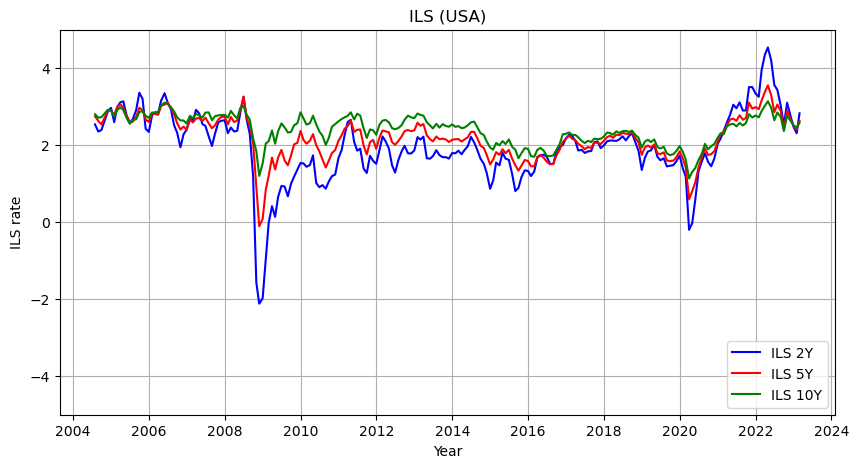

In [72]:
fig = plt.figure(figsize=(10, 5))

date = df['Date']
ils2y = df['ILS 2Y']
ils5y = df['ILS 5Y']
ils10y = df['ILS 10Y']

plt.plot(date, ils2y, color = 'blue', label = 'ILS 2Y')
plt.plot(date, ils5y, color = 'red', label = 'ILS 5Y')
plt.plot(date, ils10y, color = 'green', label = 'ILS 10Y')
plt.ylim(-5,5)
plt.grid()

plt.xlabel('Year')
plt.ylabel('ILS rate')
plt.title('ILS (USA)')

plt.legend(loc='lower right')

plt.show()


> As we can see from the graph, every ILS follows a similar behaviour throughout the years. We can notice a huge drop between 2008 and 2010 due to global financial crisis and between 2020 and 2022 because of the Covid pandemic.


**4. Most likely your data has a mean and variance that change with time. This means that the data is not stationary - which is very frequent for financial time series. Ordinary Least Squares does not work under these conditions, this is why we can not just simply run a regression of spot prices on futures prices. We need to make the data stationary first. One way to do it is to treat the data in differences, i.e. make a transform $\tilde{\pi} = \pi_t − \pi_{t−k}$. The usual practice is to take data in first differences (i.e. $i=1$), but for the purpose of the exercise, compute the differences for $k$ equal to the horizon of the ILS expressed in months.**

**Make this transform for the inflation rate, for each of the three horizons of the ILS - these will be the explained variables of the OLS regressions. For the explanatory variable, construct the time series of differences ($ils_{t,t+k} − \pi_t$), for all three horizons. This will also stationarize the data, and in this way we will create our explanatory variable. Plot the transformed series. Make sure it now has a constant mean and a more or less constant variance.**

In [73]:
df['diff_cpi2'] = df['CPI USA'].diff(periods = 24)
df['diff_cpi5'] = df['CPI USA'].diff(periods = 60)
df['diff_cpi10'] = df['CPI USA'].diff(periods = 120)

df['ilscpi2'] = df['ILS 2Y'] - df['CPI USA'].shift(periods = 24)
df['ilscpi5'] = df['ILS 5Y'] - df['CPI USA'].shift(periods = 60)
df['ilscpi10'] = df['ILS 10Y'] - df['CPI USA'].shift(periods = 120)

# print(df.to_string())

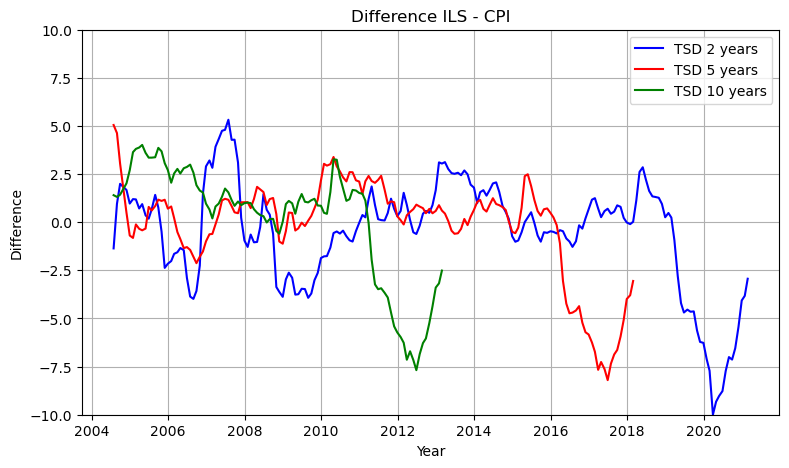

In [74]:
fig3 = plt.figure(figsize=(9, 5))

plt.plot(date, df['ilscpi2'], color = 'blue', label = 'TSD 2 years')
plt.plot(date, df['ilscpi5'], color = 'red', label = 'TSD 5 years')
plt.plot(date, df['ilscpi10'], color = 'green', label = 'TSD 10 years')

plt.xlabel('Year')
plt.ylabel('Difference')
plt.title('Difference ILS - CPI')
plt.ylim(-10,10)

plt.legend(loc='upper right')

plt.grid()

plt.show()

**5. We can now run OLS regressions (one regression for each ILS). For each type of ILS, report the estimated coefficients, t-stats and their p-values, the Rsquared. Plot the residuals - their time series and the histogram. Interpret the results. ILS of which horizon appear to be the best predictor of future inflation?**

In [87]:
df2 = df.dropna(subset=['diff_cpi2', 'ilscpi2'])

y2 = df2['diff_cpi2']                       # pi_t+k - pi_t
x2 = sm.add_constant(df2['ilscpi2'])        # \alpha + \beta * ils_t,t+k (as in regression model)
model2 = sm.OLS(y2, x2)                     # run the regression
results2 = model2.fit()                     # results

residuals2 = results2.resid                 # residuals

print(results2.summary())                   # show results

                            OLS Regression Results                            
Dep. Variable:              diff_cpi2   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.794
Method:                 Least Squares   F-statistic:                     761.9
Date:                Fri, 26 May 2023   Prob (F-statistic):           1.27e-69
Time:                        15:40:11   Log-Likelihood:                -357.14
No. Observations:                 199   AIC:                             718.3
Df Residuals:                     197   BIC:                             724.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1058      0.106      1.002      0.3

In [88]:
df5 = df.dropna(subset=['diff_cpi5', 'ilscpi5'])

y5 = df5['diff_cpi5']
x5 = sm.add_constant(df5['ilscpi5'])
model5 = sm.OLS(y5, x5)
results5 = model5.fit()

residuals5 = results5.resid

print(results5.summary())

                            OLS Regression Results                            
Dep. Variable:              diff_cpi5   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     545.3
Date:                Fri, 26 May 2023   Prob (F-statistic):           1.45e-53
Time:                        15:40:13   Log-Likelihood:                -302.78
No. Observations:                 163   AIC:                             609.6
Df Residuals:                     161   BIC:                             615.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1509      0.122     -1.232      0.2

In [89]:
df10 = df.dropna(subset=['diff_cpi10', 'ilscpi10'])

y10 = df10['diff_cpi10']
x10 = sm.add_constant(df10['ilscpi10'])
model10 = sm.OLS(y10, x10)
results10 = model10.fit()

residuals10 = results10.resid

print(results10.summary())

                            OLS Regression Results                            
Dep. Variable:             diff_cpi10   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     281.9
Date:                Fri, 26 May 2023   Prob (F-statistic):           5.48e-31
Time:                        15:40:16   Log-Likelihood:                -207.49
No. Observations:                 103   AIC:                             419.0
Df Residuals:                     101   BIC:                             424.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.181      0.391      0.6

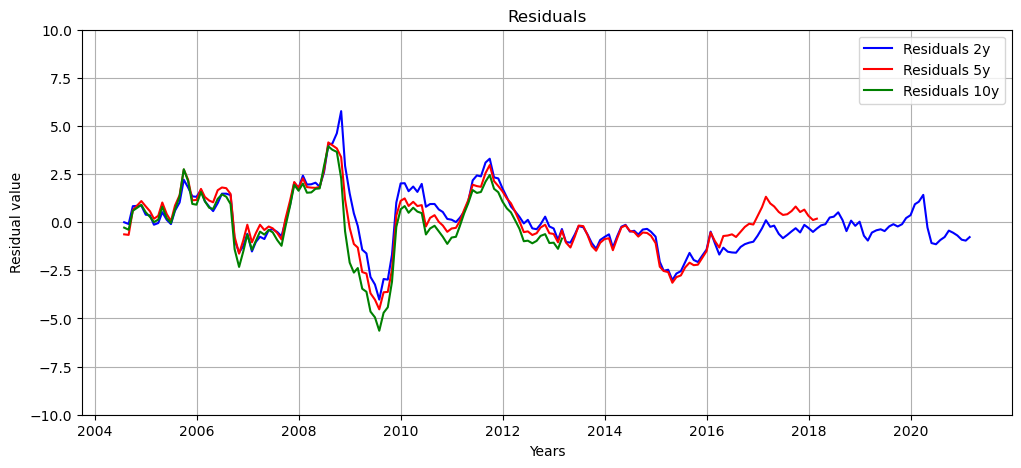

In [90]:
# Residual plot
fig = plt.figure(figsize=(12, 5))

plt.plot(df2['Date'], residuals2, color = 'blue', label = 'Residuals 2y')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='lower right')

# plt.show()

# fig = plt.figure(figsize=(9, 5))
plt.plot(df5['Date'], residuals5, color = 'red', label = 'Residuals 5y')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='lower right')

# plt.show()

# fig = plt.figure(figsize=(9, 5))
plt.plot(df10['Date'], residuals10, color = 'green', label = 'Residuals 10y')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='upper right')

plt.grid()

plt.show()

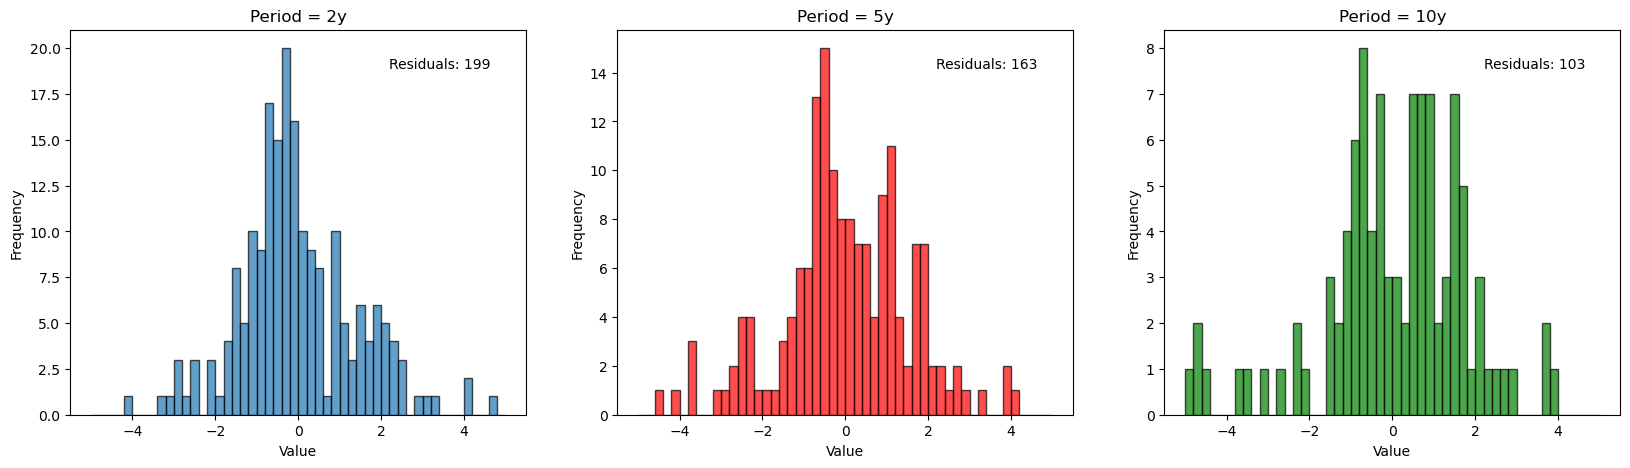

In [91]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

residuals2.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    title='Period = 2y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[0]
)
axs[0].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals2)), transform=axs[0].transAxes)
axs[0].set_xlabel('Value')

residuals5.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    color='red',
    title='Period = 5y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[1]
)
axs[1].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals5)), transform=axs[1].transAxes)
axs[1].set_xlabel('Value')

residuals10.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    color='green',
    title='Period = 10y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[2]
)
axs[2].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals10)), transform=axs[2].transAxes)
axs[2].set_xlabel('Value')

plt.show()

####################################################
# DIFFERENT Y LIMITS, can be misleading, correct!!!#
####################################################



> ???


**6. The Covid-19 crisis was a major shock to the financial and economic systems. During this period, many mechanisms did not work in the same way (for example, it was quite difficult to forecast the future demand for oil) which might have an impact on the predicting power of the ILS. Run the same regressions on the pre-covid data (end of sample December 2019). Report the results in the same form as before. Which ILS was the best predictor of future spot prices before Covid-19? If it is still the ILS of the same horizon, was it more or less informative about the future inflation?**

In [92]:
# filter before 2020
df['Date'] = pd.to_datetime(df['Date'])
selected_date = '2020-01-21'
filtered_df = df[df['Date'] <= selected_date]

# print(filtered_df.to_string())

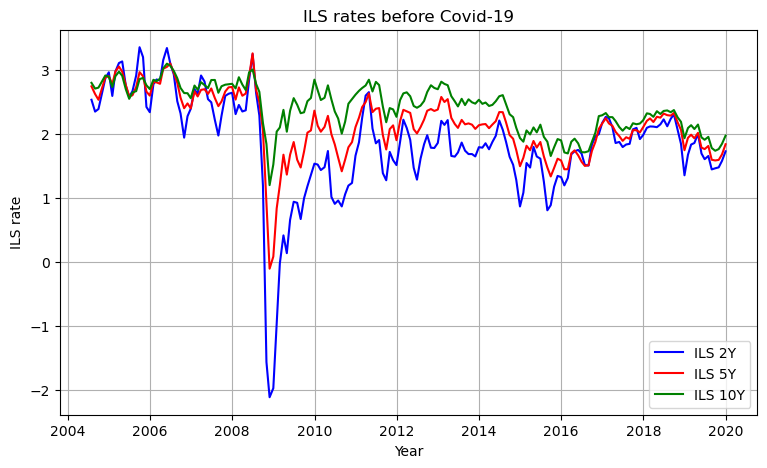

In [93]:
fig = plt.figure(figsize=(9, 5))

date = filtered_df['Date']
ils2y_filt = filtered_df['ILS 2Y']
ils5y_filt = filtered_df['ILS 5Y']
ils10y_filt = filtered_df['ILS 10Y']

plt.plot(date, ils2y_filt, color = 'blue', label = 'ILS 2Y')
plt.plot(date, ils5y_filt, color = 'red', label = 'ILS 5Y')
plt.plot(date, ils10y_filt, color = 'green', label = 'ILS 10Y')

plt.xlabel('Year')
plt.ylabel('ILS rate')
plt.title('ILS rates before Covid-19')

plt.grid()
plt.legend(loc='lower right')
plt.show()

In [94]:
filtered_df2 = filtered_df.dropna(subset=['diff_cpi2', 'ilscpi2'])

y2f = filtered_df2['diff_cpi2']                       # pi_t+k - pi_t (f = filtered = pre-covid data)
x2f = sm.add_constant(filtered_df2['ilscpi2'])        # \alpha + \beta * ils_t,t+k (as in regression model)
model2f = sm.OLS(y2f, x2f)                            # run the regression
results2f = model2f.fit()                             # fit the results

residuals2f = results2f.resid                         # residuals

print(results2f.summary())                            # show results

                            OLS Regression Results                            
Dep. Variable:              diff_cpi2   R-squared:                       0.678
Model:                            OLS   Adj. R-squared:                  0.676
Method:                 Least Squares   F-statistic:                     385.0
Date:                Fri, 26 May 2023   Prob (F-statistic):           7.05e-47
Time:                        15:40:45   Log-Likelihood:                -336.04
No. Observations:                 185   AIC:                             676.1
Df Residuals:                     183   BIC:                             682.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.1319      0.110      1.199      0.2

In [95]:
filtered_df5 = filtered_df.dropna(subset=['diff_cpi5', 'ilscpi5'])

y5f = filtered_df5['diff_cpi5']
x5f = sm.add_constant(filtered_df5['ilscpi5'])
model5f = sm.OLS(y5f, x5f)
results5f = model5f.fit()

residuals5f = results5f.resid

print(results5f.summary())

                            OLS Regression Results                            
Dep. Variable:              diff_cpi5   R-squared:                       0.772
Model:                            OLS   Adj. R-squared:                  0.771
Method:                 Least Squares   F-statistic:                     545.3
Date:                Fri, 26 May 2023   Prob (F-statistic):           1.45e-53
Time:                        15:40:47   Log-Likelihood:                -302.78
No. Observations:                 163   AIC:                             609.6
Df Residuals:                     161   BIC:                             615.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1509      0.122     -1.232      0.2

In [96]:
filtered_df10 = filtered_df.dropna(subset=['diff_cpi10', 'ilscpi10'])

y10f = filtered_df10['diff_cpi10']
x10f = sm.add_constant(filtered_df10['ilscpi10'])
model10f = sm.OLS(y10f, x10f)
results10f = model10f.fit()

residuals10f = results10f.resid

print(results10f.summary())

                            OLS Regression Results                            
Dep. Variable:             diff_cpi10   R-squared:                       0.736
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     281.9
Date:                Fri, 26 May 2023   Prob (F-statistic):           5.48e-31
Time:                        15:40:49   Log-Likelihood:                -207.49
No. Observations:                 103   AIC:                             419.0
Df Residuals:                     101   BIC:                             424.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0707      0.181      0.391      0.6

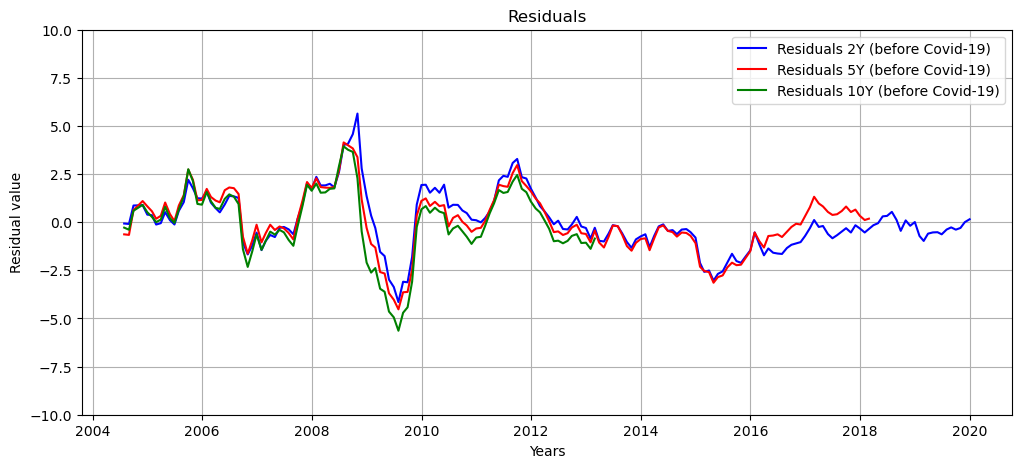

In [97]:
# Residual plot for precovid data

fig = plt.figure(figsize=(12, 5))

plt.plot(filtered_df2['Date'], residuals2f, color = 'blue', label = 'Residuals 2Y (before Covid-19)')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='lower right')

# plt.show()

# fig = plt.figure(figsize=(9, 5))
plt.plot(filtered_df5['Date'], residuals5f, color = 'red', label = 'Residuals 5Y (before Covid-19)')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='lower right')

# plt.show()

# fig = plt.figure(figsize=(9, 5))
plt.plot(filtered_df10['Date'], residuals10f, color = 'green', label = 'Residuals 10Y (before Covid-19)')
plt.ylim(-10, 10)

plt.xlabel('Years')
plt.ylabel('Residual value')
plt.title('Residuals')
plt.legend(loc='upper right')

plt.grid()

plt.show()
print()

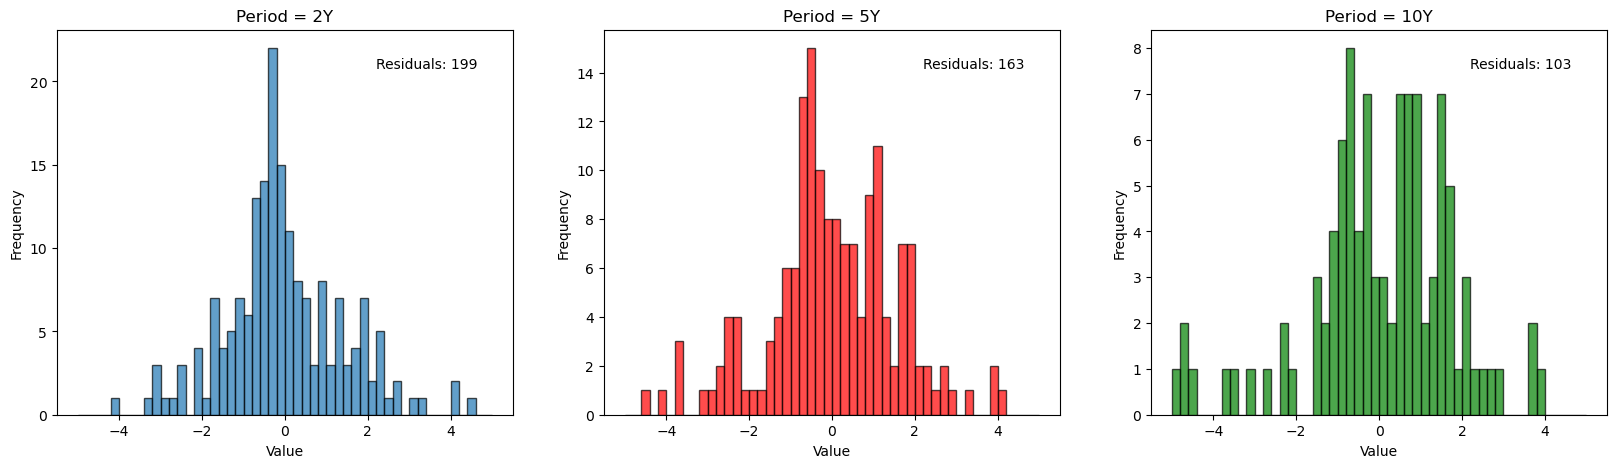

In [98]:
fig, axs = plt.subplots(1, 3, figsize=(20, 5))

residuals2f.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    title='Period = 2Y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[0]
)
axs[0].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals2)), transform=axs[0].transAxes)
axs[0].set_xlabel('Value')


residuals5f.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    color='red',
    title='Period = 5Y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[1]
)
axs[1].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals5)), transform=axs[1].transAxes)
axs[1].set_xlabel('Value')


residuals10f.plot.hist(
    bins=50,
    range=(-5, 5),
    edgecolor='black',
    alpha=0.7,
    color='green',
    title='Period = 10Y',
    xlabel='Values',
    ylabel='Frequency',
    ax=axs[2]
)
axs[2].text(0.7, 0.9, 'Residuals: {}'.format(len(residuals10)), transform=axs[2].transAxes)
axs[2].set_xlabel('Value')


plt.show()

####################################################
# DIFFERENT Y LIMITS, can be misleading, correct!!!#
####################################################